In [139]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from jedi.inference.value import iterable

from glacier_data import load_glacier_dataset, get_record


In [140]:
# props: one row per glacier, indexed by ID
# records: long format (ID, name, year, dL_m, source), one row per data point
props, records = load_glacier_dataset()

# Attach metadata to every data point, e.g. to filter by region or scale by L_1950
data = records.join(props.drop(columns='name'), on='ID')
data.head()

,ID,name,year,dL_m,source,num,region,lat,lon,area_km2,L1950_km,hmax_m,hmin_m,slope,precip_m_per_a,n_data,first,last
0,428,Bear,1835,0.00000,4,1,1,59.99000,-149.63000,149.28000,35.33000,1752.00000,4.00000,0.07461,6.00000,12,1835,2007
1,428,Bear,1888,0.00000,3,1,1,59.99000,-149.63000,149.28000,35.33000,1752.00000,4.00000,0.07461,6.00000,12,1835,2007
2,428,Bear,1909,-1863.00000,3,1,1,59.99000,-149.63000,149.28000,35.33000,1752.00000,4.00000,0.07461,6.00000,12,1835,2007
3,428,Bear,1951,-4093.00000,1,1,1,59.99000,-149.63000,149.28000,35.33000,1752.00000,4.00000,0.07461,6.00000,12,1835,2007
4,428,Bear,1983,-12530.00000,1,1,1,59.99000,-149.63000,149.28000,35.33000,1752.00000,4.00000,0.07461,6.00000,12,1835,2007


In [149]:
c1 = 1e-3
c2 = 1

In [150]:
def CalculateClimateProperties(GlacierFrame: pd.DataFrame, c1 = c1, c2 = c2):
    '''
    Calculate glacier sensitivity and response time
    :param Precip: Precipitation
    :param s: Avg slope of glacier
    :param c1: constant
    :param L: glacier length
    :return: Climate properties
    '''
    Precip = GlacierFrame['precip_m_per_a'].values[0]
    s = GlacierFrame['slope'].values[0]
    L = GlacierFrame['L1950_km'].values[0]*1e3
    beta = 0.0006*np.sqrt(Precip)
    gamma = c1*s/np.sqrt(Precip)
    tau =  c2*1/(beta*s*np.sqrt(1+20*s)*np.sqrt(L))
    return gamma, tau

BearGlacier = data[data['name'] == "Bear"]
CalculateClimateProperties(BearGlacier)


(np.float64(3.0457363710056508e-05), np.float64(30.736232904630025))

In [151]:
#get list of valid glacier IDs

ids = data["ID"].unique()
GlacierSensProps = []

for calculation_id, glacier_id in enumerate(ids):
    glacier = data[data["ID"] == glacier_id]
    gamma, tau = CalculateClimateProperties(glacier)

    if tau < 0:
        print(f"Invalid glacier ID {glacier_id} in calculation {calculation_id}")
        continue

    GlacierSensProps.append({
        "calculation_id": calculation_id,
        "glacier_id": glacier_id,
        "gamma": gamma,
        "tau": tau,
    })


Invalid glacier ID 489 in calculation 129


In [152]:
gammas = [gi["gamma"] for gi in GlacierSensProps]
tau = [ti["tau"] for ti in GlacierSensProps]
GlacierSensProps = pd.DataFrame(GlacierSensProps)

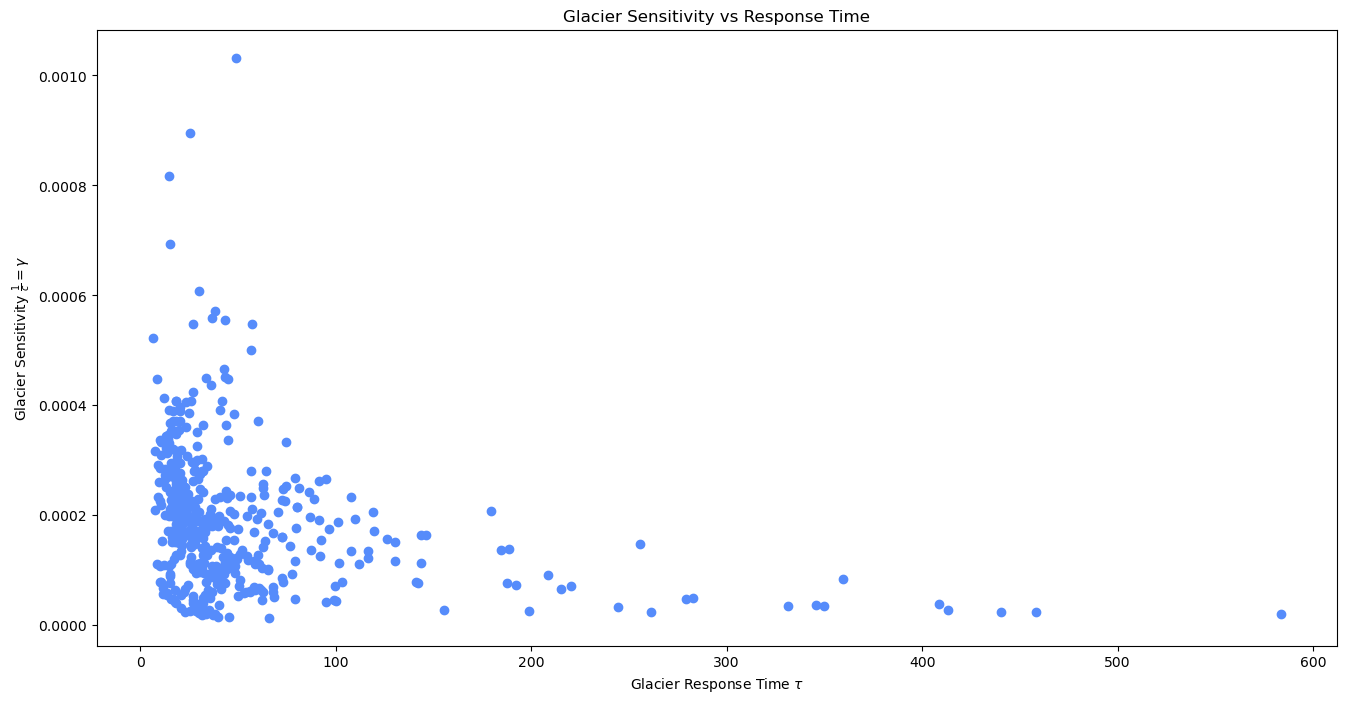

In [153]:
plt.figure(figsize=(16,8))
plt.scatter(tau, gammas)
plt.ylabel(r'Glacier Sensitivity $\frac{1}{c}=\gamma$')
plt.xlabel(r'Glacier Response Time $\tau$')
plt.title('Glacier Sensitivity vs Response Time')
plt.show()



In [177]:
Id = BearGlacier['ID'][0]
Leng = BearGlacier['L1950_km']*1e3+BearGlacier['dL_m']
Time = BearGlacier['year']
sens = GlacierSensProps[GlacierSensProps['glacier_id'] == Id]
gamma = sens['gamma'][0]
tau = sens['tau'][0]


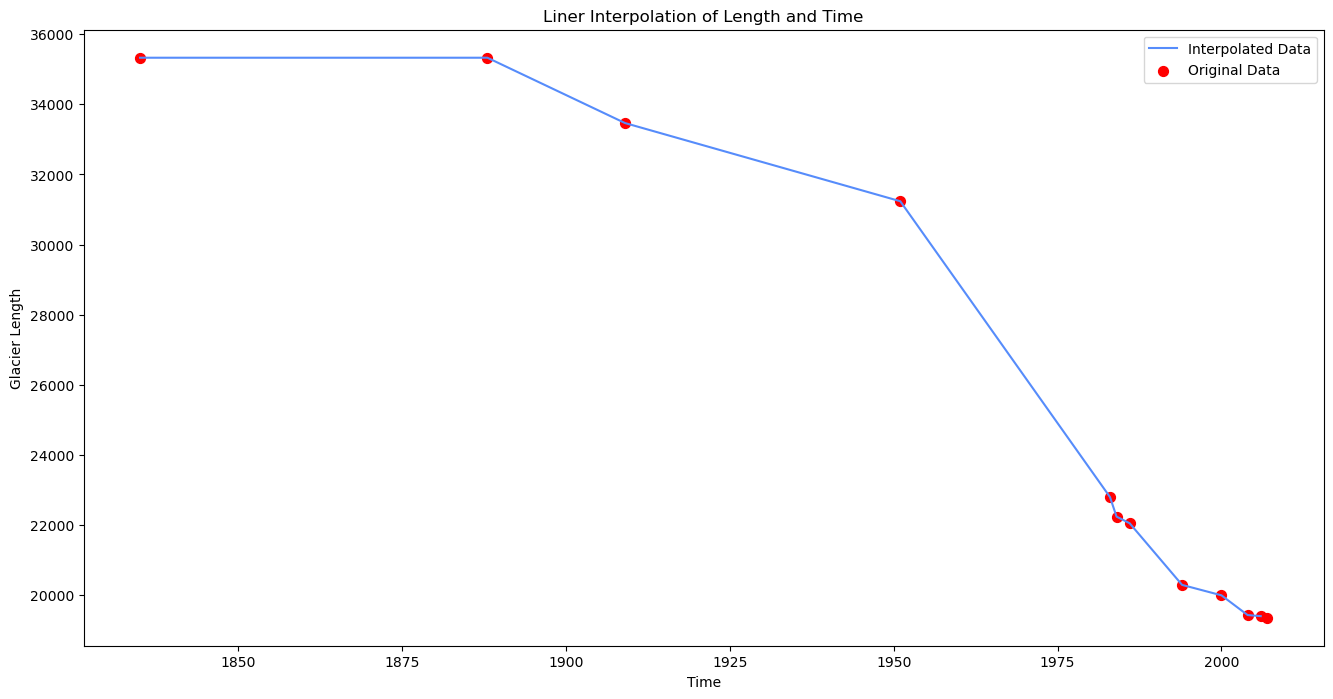

In [178]:
SmoothTime = np.arange(Time.iloc[0], Time.iloc[-1], 1)
InterpLength = np.interp(SmoothTime, Time, Leng)
plt.figure(figsize=(16,8))
plt.plot(SmoothTime, InterpLength, label='Interpolated Data')
plt.scatter(Time,Leng, c='red', s=50, label= 'Original Data')
plt.xlabel('Time')
plt.ylabel('Glacier Length')
plt.title('Liner Interpolation of Length and Time')
plt.legend()
plt.show()

In [198]:
def PrepData(id: float, c1 = c1, c2 = c2):
    '''
    :param id: Id af gletsjer som skal inverteres
    :return:
    '''
    Glacier = data[data["ID"] == id]
    Leng = Glacier['L1950_km']*1e3+Glacier['dL_m']
    Time = Glacier['year']


    SensitivityProperties = CalculateClimateProperties(Glacier)
    gamma = SensitivityProperties[0]
    tau = SensitivityProperties[1]


    SmoothTime = np.arange(Time.iloc[0], Time.iloc[-1], 1)
    InterpLength = np.interp(SmoothTime, Time, Leng)
    return  gamma, tau, SmoothTime, InterpLength

In [199]:
def InvertLength(L : any, Time: any, c: float, tau: float ):
    '''
    Invert Glacier length data for Temperature
    :param L: Glacier Length with respect to reference state
    :param c: Glacier Sensitivity
    :param tau: Glacier Response Time
    :return: Temperature pertubation with respect to reference state
    '''
    dLDt = np.gradient(L, Time)
    T = -1/c*(L+tau*dLDt)
    return T


Temp = InvertLength(L = Leng, Time = Time, c= 1/gamma, tau = tau)

In [206]:
def RunModel(id: float, c1 = c1, c2 = c2):
    '''
    Run the model for a specific glacier
    :param id: Id of the glacier
    :return: Invertion to temperature
    '''
    gamma, tau, SmoothTime, InterpLength = PrepData(id, c1, c2)

    return InvertLength(L = InterpLength, Time = SmoothTime, c= 1/gamma, tau = tau), SmoothTime

Temp, ModelTime = RunModel(BearGlacier['ID'][0], 5, 5)

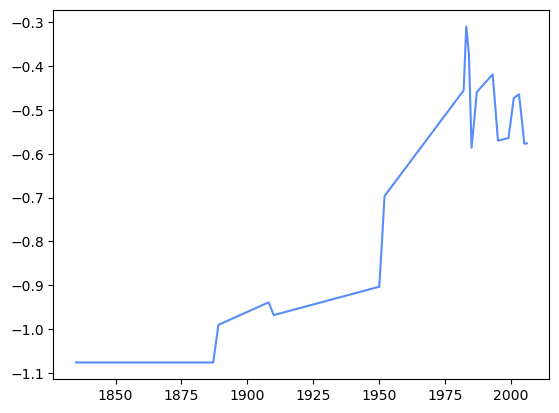

In [207]:
plt.plot(ModelTime, Temp)